# **Setup**

In [ ]:
from pathlib import Path

import sys
import pandas as pd
import numpy as np
import IPython
import matplotlib as mpl
from IPython.display import display, Markdown, Latex, HTML, IFrame, JSON, Code, Image, YouTubeVideo, clear_output
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
print( f"Python {sys.version}" )
print( f"Pandas {pd.__version__}" )
print( f"NumPy {np.__version__}" )
print( f"IPython {IPython.__version__}" )
print( f"Matplotlib {mpl.__version__}" )

Python 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
Pandas 2.2.3
NumPy 2.1.3
IPython 7.34.0
Matplotlib 3.10.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#**Compare Production vs Consumption Across Countries**

## Load and pick the countries to compare

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/DADS5001/ico_coffee_long_with_population.csv')
print(f"Loaded {len(df):,} rows, {df['Country'].nunique()} countries")

COUNTRIES = ["Thailand", "Philippines"]

subset = df[(df.Country.isin(COUNTRIES)) & (df.Metric.isin(["production_kg", "domestic_consumption_kg"]))].copy()
subset["value_million_kg"] = subset["value"] / 1e6
subset["Metric_label"] = subset["Metric"].map({
    "production_kg": "Production",
    "domestic_consumption_kg": "Domestic Consumption", })

print(f"Rows for the {len(COUNTRIES)} selected countries: {len(subset):,}")
subset

Loaded 8,640 rows, 91 countries
Rows for the 2 selected countries: 120


,Country,Coffee type,Metric,Year,value,is_imputed,population,value_million_kg,Metric_label
1200,Philippines,Robusta/Arabica,domestic_consumption_kg,1990.0,43200000.0,False,62854666.0,43.20,Domestic Consumption
1201,Philippines,Robusta/Arabica,domestic_consumption_kg,1991.0,45000000.0,False,64382249.0,45.00,Domestic Consumption
1202,Philippines,Robusta/Arabica,domestic_consumption_kg,1992.0,45000000.0,False,65926125.0,45.00,Domestic Consumption
1203,Philippines,Robusta/Arabica,domestic_consumption_kg,1993.0,46200000.0,False,67530621.0,46.20,Domestic Consumption
1204,Philippines,Robusta/Arabica,domestic_consumption_kg,1994.0,47400000.0,False,69019291.0,47.40,Domestic Consumption
...,...,...,...,...,...,...,...,...,...
7315,Thailand,Robusta/Arabica,production_kg,2015.0,45720000.0,False,70540795.0,45.72,Production
7316,Thailand,Robusta/Arabica,production_kg,2016.0,32280000.0,False,70859841.0,32.28,Production
7317,Thailand,Robusta/Arabica,production_kg,2017.0,38280000.0,False,71160187.0,38.28,Production
7318,Thailand,Robusta/Arabica,production_kg,2018.0,28920000.0,False,71376079.0,28.92,Production


## Plot

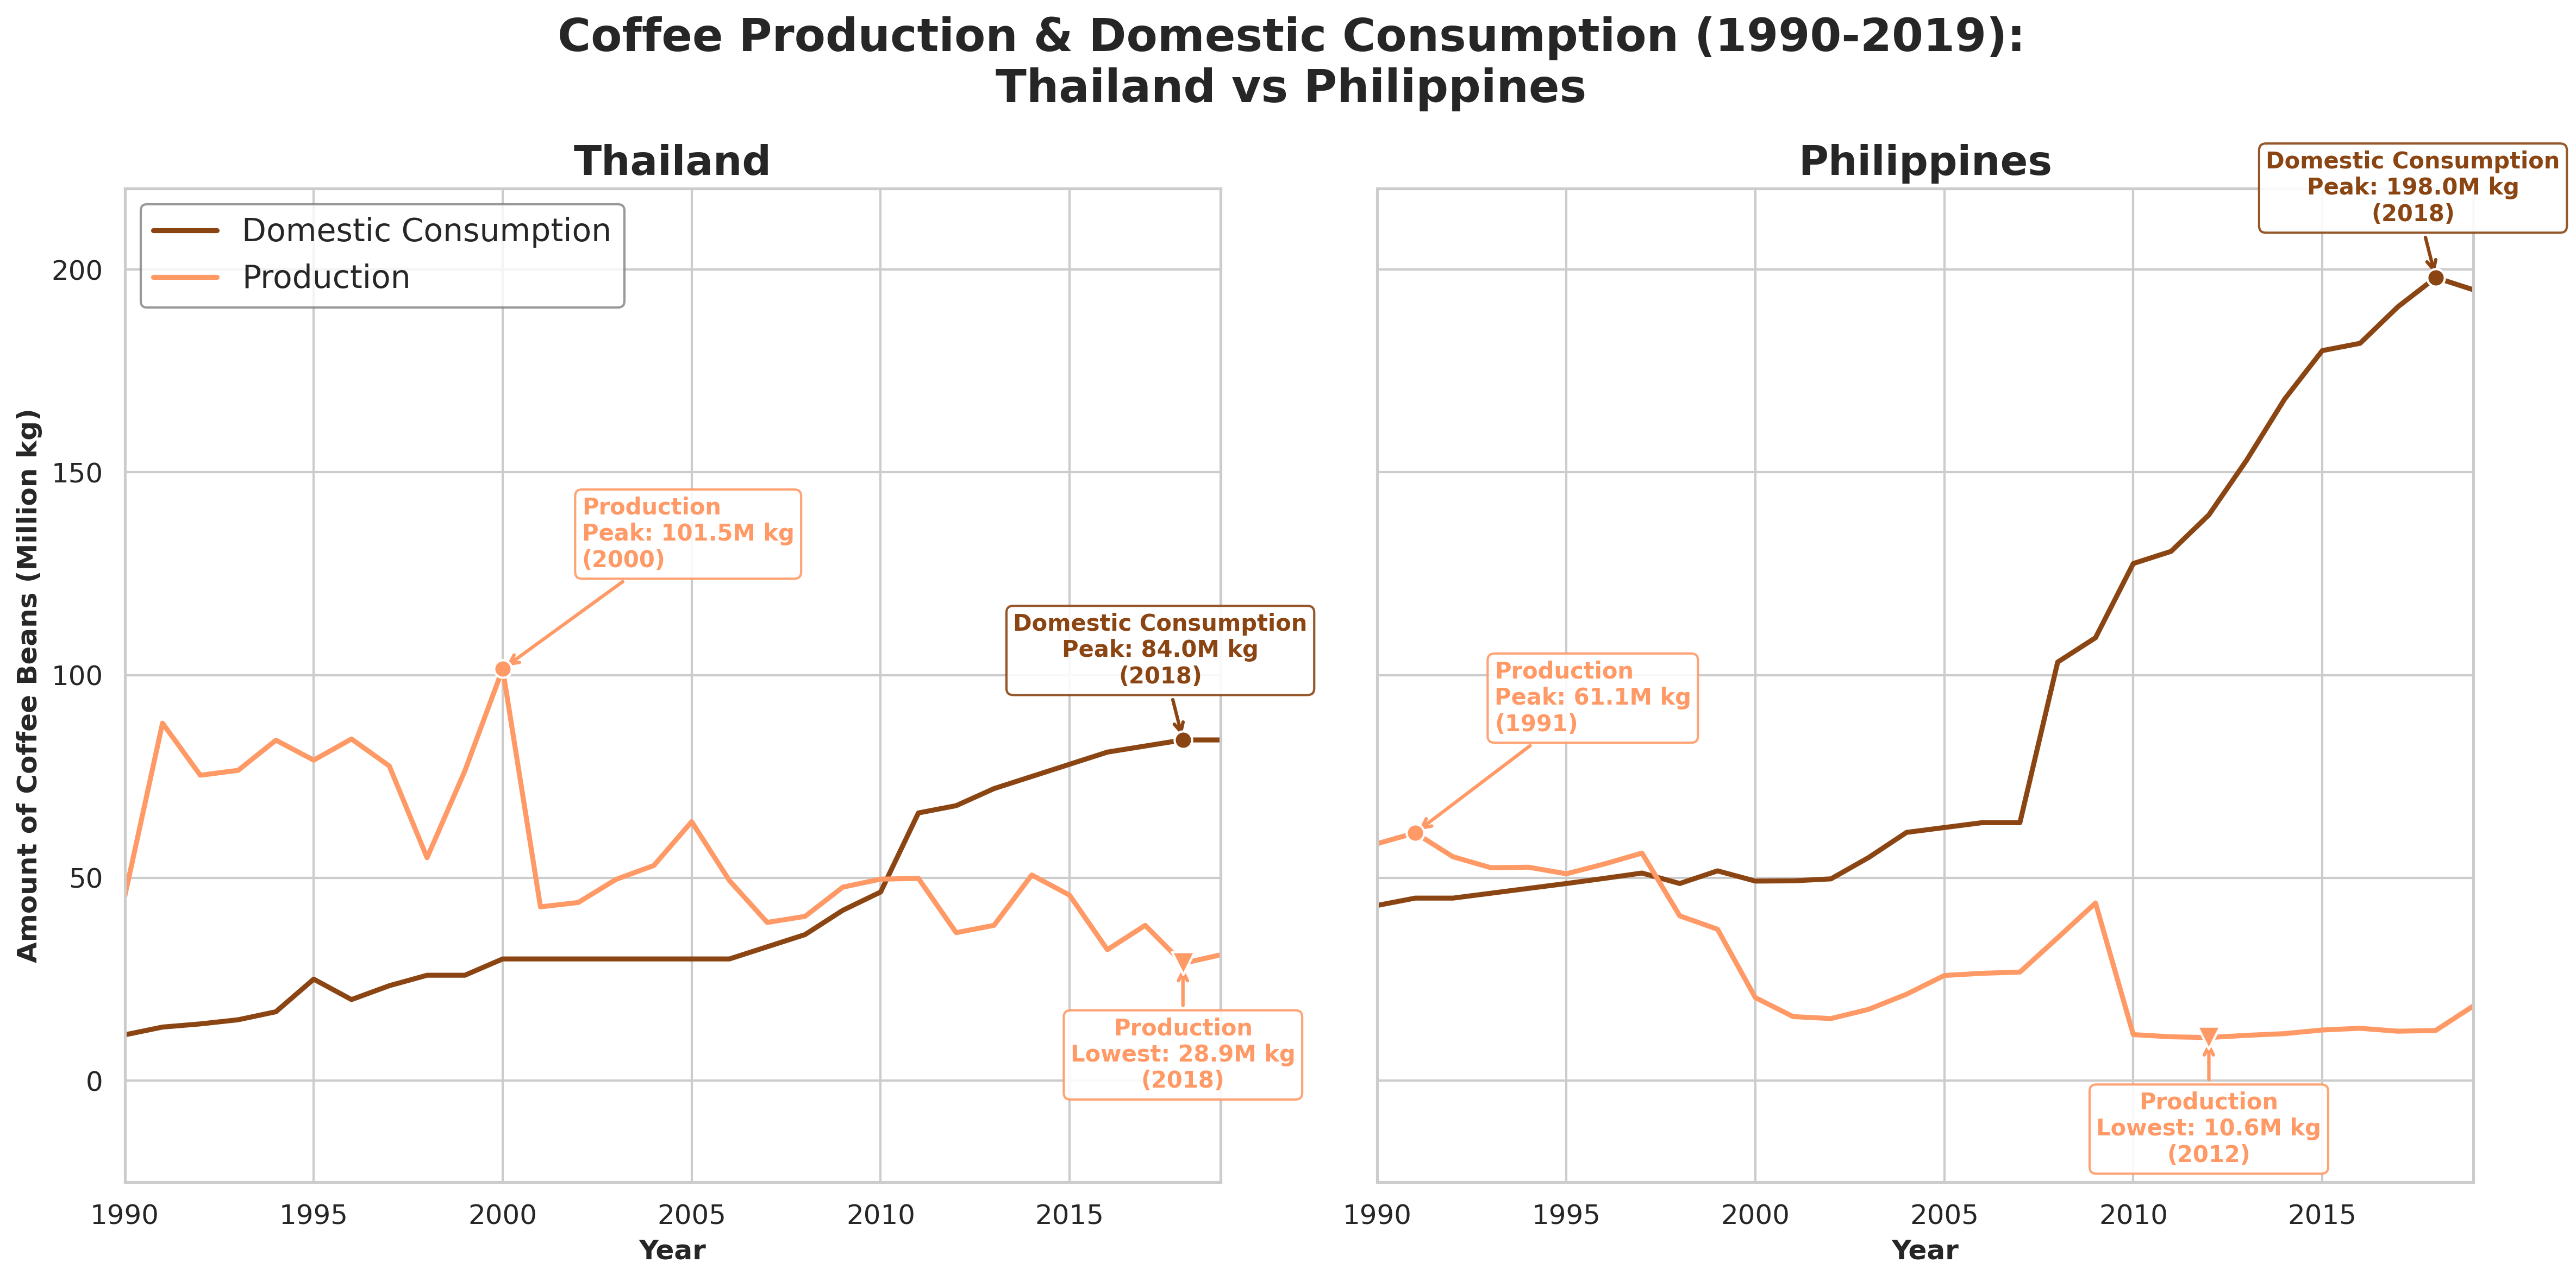

In [ ]:
n = len(COUNTRIES)
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True, dpi=300)
PALETTE = {"Production": "#FF9966", "Domestic Consumption": "#8B4513"}

for ax, country in zip(axes, COUNTRIES):
    country_df = subset[subset.Country == country].sort_values("Year")
    sns.lineplot(data=country_df, x="Year", y="value_million_kg", hue="Metric_label",
                 ax=ax, linewidth=2.2, palette=PALETTE, legend=(country == COUNTRIES[0]))
    ax.set_title(country, fontsize=18, fontweight="bold")
    ax.set_xlabel("Year", fontweight="bold")
    ax.set_ylabel("Amount of Coffee Beans (Million kg)" if country == COUNTRIES[0] else "", fontweight="bold")
    ax.set_xlim(1990, 2019)
    ax.set_ylim(-25, 220)     # extra headroom at the bottom for "lowest" labels
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # --- Annotate the peak (max) point for each metric ---
    for metric in country_df["Metric_label"].unique():
        metric_df = country_df[country_df["Metric_label"] == metric]
        peak_row = metric_df.loc[metric_df["value_million_kg"].idxmax()]
        peak_year = int(peak_row["Year"])
        peak_val = peak_row["value_million_kg"]

        if metric == "Production":
            xytext = (35, 45)
            ha = 'left'
        else:
            xytext = (-10, 25)
            ha = 'center'

        ax.annotate(
            f'{metric}\nPeak: {peak_val:.1f}M kg\n({peak_year})',
            xy=(peak_year, peak_val),
            xytext=xytext, textcoords="offset points",
            ha=ha, fontsize=10, fontweight="bold",
            color=PALETTE[metric],
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=PALETTE[metric], alpha=0.9),
            arrowprops=dict(arrowstyle="->", color=PALETTE[metric], lw=1.5)
        )
        ax.scatter([peak_year], [peak_val], color=PALETTE[metric], s=60, zorder=5,
                   edgecolor="white", linewidth=1)

    # --- Annotate the lowest (min) Production point ---
    prod_df = country_df[country_df["Metric_label"] == "Production"]
    low_row = prod_df.loc[prod_df["value_million_kg"].idxmin()]
    low_year = int(low_row["Year"])
    low_val = low_row["value_million_kg"]

    # push straight down into the empty margin created by ylim, instead of sideways into the lines
    ax.annotate(
        f'Production\nLowest: {low_val:.1f}M kg\n({low_year})',
        xy=(low_year, low_val),
        xytext=(0, -55), textcoords="offset points",
        ha='center', fontsize=10, fontweight="bold",
        color=PALETTE["Production"],
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=PALETTE["Production"], alpha=0.9),
        arrowprops=dict(arrowstyle="->", color=PALETTE["Production"], lw=1.5)
    )
    ax.scatter([low_year], [low_val], color=PALETTE["Production"], s=100, zorder=5,
               edgecolor="white", linewidth=1, marker='v')

axes[0].legend(loc="upper left", frameon=True, fontsize=14, title="", facecolor="white", edgecolor="grey", framealpha=0.8)
fig.suptitle("Coffee Production & Domestic Consumption (1990-2019):\nThailand vs Philippines", fontsize=20, fontweight="bold")

plt.tight_layout()
plt.savefig("production&consumption_THvsPH.png", dpi=300, facecolor="white", bbox_inches="tight")
plt.show()